## Import libs

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.data import Dataset
import seaborn as sns


from models.unfair_lr.models import UnfairLogisticRegression
from models.unfair_lr.learning import train_loop
from util.evaluation import *
from util.load_data import load_data

/Users/lffpl/Projects/falsb/env/falsb/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Preliminaries

In [2]:
batch_size = 64
epochs = 100
lr = 0.001

In [3]:
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'heart'

In [5]:
x, y, a = load_data(data_name)
raw_data = (x, y, a)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
adim = a.shape[1]
zdim = 8

In [7]:
print(xdim, ydim, adim)

25 1 1


## Result file

In [8]:
header = "model_name", "cv_seed", "clas_acc", "dp", "deqodds", "deqopp", "trade_dp", "trade_deqodds", "trade_deqopp", "TN_a0", "FP_a0", "FN_a0", "TP_a0", "TN_a1", "FP_a1", "FN_a1", "TP_a1"
results = []

## Testing

In [9]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

2026-01-03 18:05:35.211615: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch | Class Loss | Class Acc
> 1 | 0.782866358757019 | 0.5142045454545454
> 2 | 0.7741034626960754 | 0.5142045454545454
> 3 | 0.7686025500297546 | 0.5142045454545454


2026-01-03 18:05:35.268460: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-03 18:05:35.382924: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 4 | 0.7645806670188904 | 0.5142045454545454
> 5 | 0.7614123225212097 | 0.5142045454545454
> 6 | 0.7588003873825073 | 0.5142045454545454
> 7 | 0.7565800547599792 | 0.5142045454545454
> 8 | 0.7546500563621521 | 0.5142045454545454
> 9 | 0.7529439926147461 | 0.5142045454545454
> 10 | 0.7514159083366394 | 0.5142045454545454


2026-01-03 18:05:35.616460: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

> 67 | 0.7240278720855713 | 0.5142045454545454
> 68 | 0.723818302154541 | 0.5142045454545454
> 69 | 0.7236118316650391 | 0.5142045454545454
> 70 | 0.7234084010124207 | 0.5142045454545454
> 71 | 0.723207950592041 | 0.5142045454545454
> 72 | 0.7230104207992554 | 0.5142045454545454
> 73 | 0.7228155732154846 | 0.5142045454545454
> 74 | 0.7226234674453735 | 0.5142045454545454
> 75 | 0.7224341034889221 | 0.5142045454545454
> 76 | 0.7222472429275513 | 0.5142045454545454
> 77 | 0.7220629453659058 | 0.5142045454545454
> 78 | 0.7218810319900513 | 0.5142045454545454
> 79 | 0.7217015027999878 | 0.5142045454545454
> 80 | 0.7215242385864258 | 0.5142045454545454
> 81 | 0.7213493585586548 | 0.5142045454545454
> 82 | 0.7211765646934509 | 0.5142045454545454
> 83 | 0.721005916595459 | 0.5142045454545454
> 84 | 0.7208374738693237 | 0.5142045454545454
> 85 | 0.7206709980964661 | 0.5142045454545454
> 86 | 0.7205065488815308 | 0.5142045454545454
> 87 | 0.720344066619873 | 0.5142045454545454
> 88 | 0.72018343

2026-01-03 18:05:42.243469: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 30 | 0.7693483233451843 | 0.5170454545454546
> 31 | 0.7687764167785645 | 0.5170454545454546
> 32 | 0.7682228088378906 | 0.5170454545454546
> 33 | 0.767686665058136 | 0.5170454545454546
> 34 | 0.7671667337417603 | 0.5170454545454546
> 35 | 0.7666621208190918 | 0.5170454545454546
> 36 | 0.766171932220459 | 0.5170454545454546
> 37 | 0.7656953930854797 | 0.5170454545454546
> 38 | 0.7652318477630615 | 0.5170454545454546
> 39 | 0.7647805213928223 | 0.5170454545454546
> 40 | 0.7643407583236694 | 0.5170454545454546
> 41 | 0.7639122009277344 | 0.5170454545454546
> 42 | 0.7634940147399902 | 0.5170454545454546
> 43 | 0.7630858421325684 | 0.5170454545454546
> 44 | 0.7626873254776001 | 0.5170454545454546
> 45 | 0.7622979283332825 | 0.5170454545454546
> 46 | 0.761917233467102 | 0.5170454545454546
> 47 | 0.7615448236465454 | 0.5170454545454546
> 48 | 0.7611804604530334 | 0.5170454545454546
> 49 | 0.7608238458633423 | 0.5170454545454546
> 50 | 0.7604745030403137 | 0.5170454545454546
> 51 | 0.7601321

2026-01-03 18:05:49.473433: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 55 | 0.7620801329612732 | 0.5269886363636364
> 56 | 0.7618383169174194 | 0.5269886363636364
> 57 | 0.7616009712219238 | 0.5269886363636364
> 58 | 0.761367917060852 | 0.5269886363636364
> 59 | 0.7611387968063354 | 0.5269886363636364
> 60 | 0.7609137296676636 | 0.5269886363636364
> 61 | 0.7606924772262573 | 0.5269886363636364
> 62 | 0.7604748606681824 | 0.5269886363636364
> 63 | 0.7602608799934387 | 0.5269886363636364
> 64 | 0.7600502371788025 | 0.5269886363636364
> 65 | 0.759843111038208 | 0.5269886363636364
> 66 | 0.7596391439437866 | 0.5269886363636364
> 67 | 0.7594383358955383 | 0.5269886363636364
> 68 | 0.7592405080795288 | 0.5269886363636364
> 69 | 0.7590457201004028 | 0.5269886363636364
> 70 | 0.7588537931442261 | 0.5269886363636364
> 71 | 0.7586647272109985 | 0.5269886363636364
> 72 | 0.7584782838821411 | 0.5269886363636364
> 73 | 0.7582945227622986 | 0.5269886363636364
> 74 | 0.7581133246421814 | 0.5269886363636364
> 75 | 0.7579345703125 | 0.5269886363636364
> 76 | 0.757758378

<Axes: >

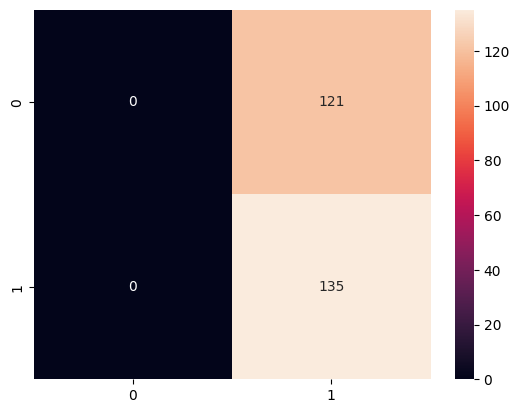

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

In [11]:
for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a_train, a_test = train_test_split(
        x, y, a, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    # train below

    opt = Adam(learning_rate=lr)

    model = UnfairLogisticRegression(xdim, ydim, batch_size)
    ret = train_loop(model, train_data, epochs, opt)
    Y, A, Y_hat = evaluation(model, test_data)
    
    clas_acc, dp, deqodds, deqopp, confusion_matrix, metrics_a0, metrics_a1  = compute_metrics(Y, A, Y_hat, adim=adim)
    
    fair_metrics = (dp, deqodds, deqopp)
    
    tradeoff = []
    
    for fair_metric in fair_metrics:
        tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
    
    result = ['UnfairLR', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    results.append(result)

    del(opt)

> Epoch | Class Loss | Class Acc
> 1 | 0.782866358757019 | 0.5142045454545454
> 2 | 0.7664240002632141 | 0.5142045454545454
> 3 | 0.7505770921707153 | 0.5142045454545454
> 4 | 0.7353758811950684 | 0.5142045454545454
> 5 | 0.7208115458488464 | 0.5142045454545454
> 6 | 0.7068582773208618 | 0.5142045454545454
> 7 | 0.693486750125885 | 0.5142045454545454
> 8 | 0.6806692481040955 | 0.5142045454545454
> 9 | 0.6683804988861084 | 0.5142045454545454


2026-01-03 18:06:03.312613: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 10 | 0.6565974950790405 | 0.5142045454545454
> 11 | 0.6452991962432861 | 0.5142045454545454
> 12 | 0.6344655752182007 | 0.5170454545454546
> 13 | 0.6240779757499695 | 0.5255681818181818
> 14 | 0.6141184568405151 | 0.5539772727272727
> 15 | 0.6045694351196289 | 0.5809659090909091
> 16 | 0.5954141616821289 | 0.6107954545454546
> 17 | 0.586636483669281 | 0.6335227272727273
> 18 | 0.5782203674316406 | 0.6647727272727273
> 19 | 0.5701504945755005 | 0.7002840909090909
> 20 | 0.5624119639396667 | 0.7215909090909091
> 21 | 0.5549904108047485 | 0.7414772727272727
> 22 | 0.5478718280792236 | 0.7585227272727273
> 23 | 0.541042685508728 | 0.7741477272727273
> 24 | 0.5344902276992798 | 0.7855113636363636
> 25 | 0.5282018780708313 | 0.7997159090909091
> 26 | 0.5221655964851379 | 0.8110795454545454
> 27 | 0.5163699388504028 | 0.8167613636363636
> 28 | 0.5108039379119873 | 0.8238636363636364
> 29 | 0.5054569840431213 | 0.8267045454545454
> 30 | 0.5003189444541931 | 0.828125
> 31 | 0.4953803718090057

<Axes: >

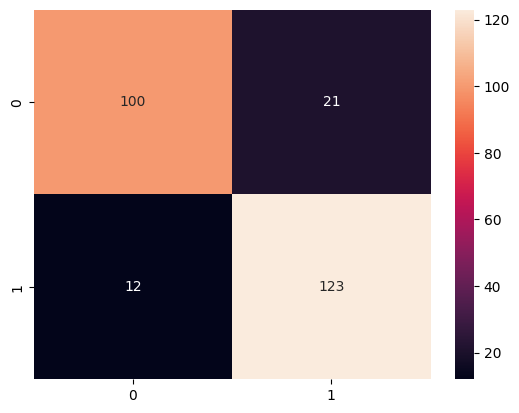

In [12]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [13]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,UnfairLR-decay,13,0.527344,1.000000,1.000000,1.000000,0.690537,0.690537,0.690537,0.0,22.0,0.0,60.0,0.0,99.0,0.0,75.0
1,UnfairLR-decay,29,0.519531,1.000000,1.000000,1.000000,0.683805,0.683805,0.683805,0.0,21.0,0.0,56.0,0.0,102.0,0.0,77.0
2,UnfairLR-decay,42,0.488281,1.000000,1.000000,1.000000,0.656168,0.656168,0.656168,0.0,25.0,0.0,56.0,0.0,106.0,0.0,69.0
3,UnfairLR-decay,55,0.515625,1.000000,1.000000,1.000000,0.680412,0.680412,0.680412,0.0,20.0,0.0,57.0,0.0,104.0,0.0,75.0
4,UnfairLR-decay,73,0.527344,1.000000,1.000000,1.000000,0.690537,0.690537,0.690537,0.0,24.0,0.0,69.0,0.0,97.0,0.0,66.0
5,UnfairLR,13,0.847656,0.703673,0.832727,0.786667,0.768983,0.840125,0.816023,20.0,2.0,0.0,60.0,78.0,21.0,16.0,59.0
6,UnfairLR,29,0.886719,0.686280,0.926471,0.857143,0.773729,0.906159,0.871680,18.0,3.0,0.0,56.0,87.0,15.0,11.0,66.0
7,UnfairLR,42,0.835938,0.685996,0.885746,0.843944,0.753581,0.860121,0.839922,18.0,7.0,1.0,55.0,84.0,22.0,12.0,57.0
8,UnfairLR,55,0.839844,0.717986,0.915246,0.870877,0.774149,0.875925,0.855079,16.0,4.0,1.0,56.0,79.0,25.0,11.0,64.0
9,UnfairLR,73,0.871094,0.684412,0.893630,0.847826,0.766551,0.882218,0.859302,21.0,3.0,1.0,68.0,79.0,18.0,11.0,55.0


In [14]:
result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')